In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import stylia
from stylia import ArticleColors, save_figure
from stylia import CategoricalPalette
stylia.set_format("slide")
stylia.set_style("ersilia")
pal = CategoricalPalette("ersilia")

plt.rcParams["figure.dpi"] = 300

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Load metadata and pathogen names
metadata = pd.read_csv(os.path.join(REPO_ROOT, "data", "processed", "01_chembl_datasets_all.csv"))
pathogens = pd.read_csv(os.path.join(REPO_ROOT, "config", "pathogens.csv"))
code_to_name = dict(zip(pathogens["code"], pathogens["pathogen"]))
counts = (metadata.groupby("pathogen").size().reset_index(name="n_datasets").sort_values("n_datasets", ascending=True))
counts["name"] = counts["pathogen"].map(code_to_name)

# Load models report
report = pd.read_csv(os.path.join(REPO_ROOT, "output", "results", "09_reports.csv"))

Pathogen: Acinetobacter baumannii
Processed datasets: 4/5


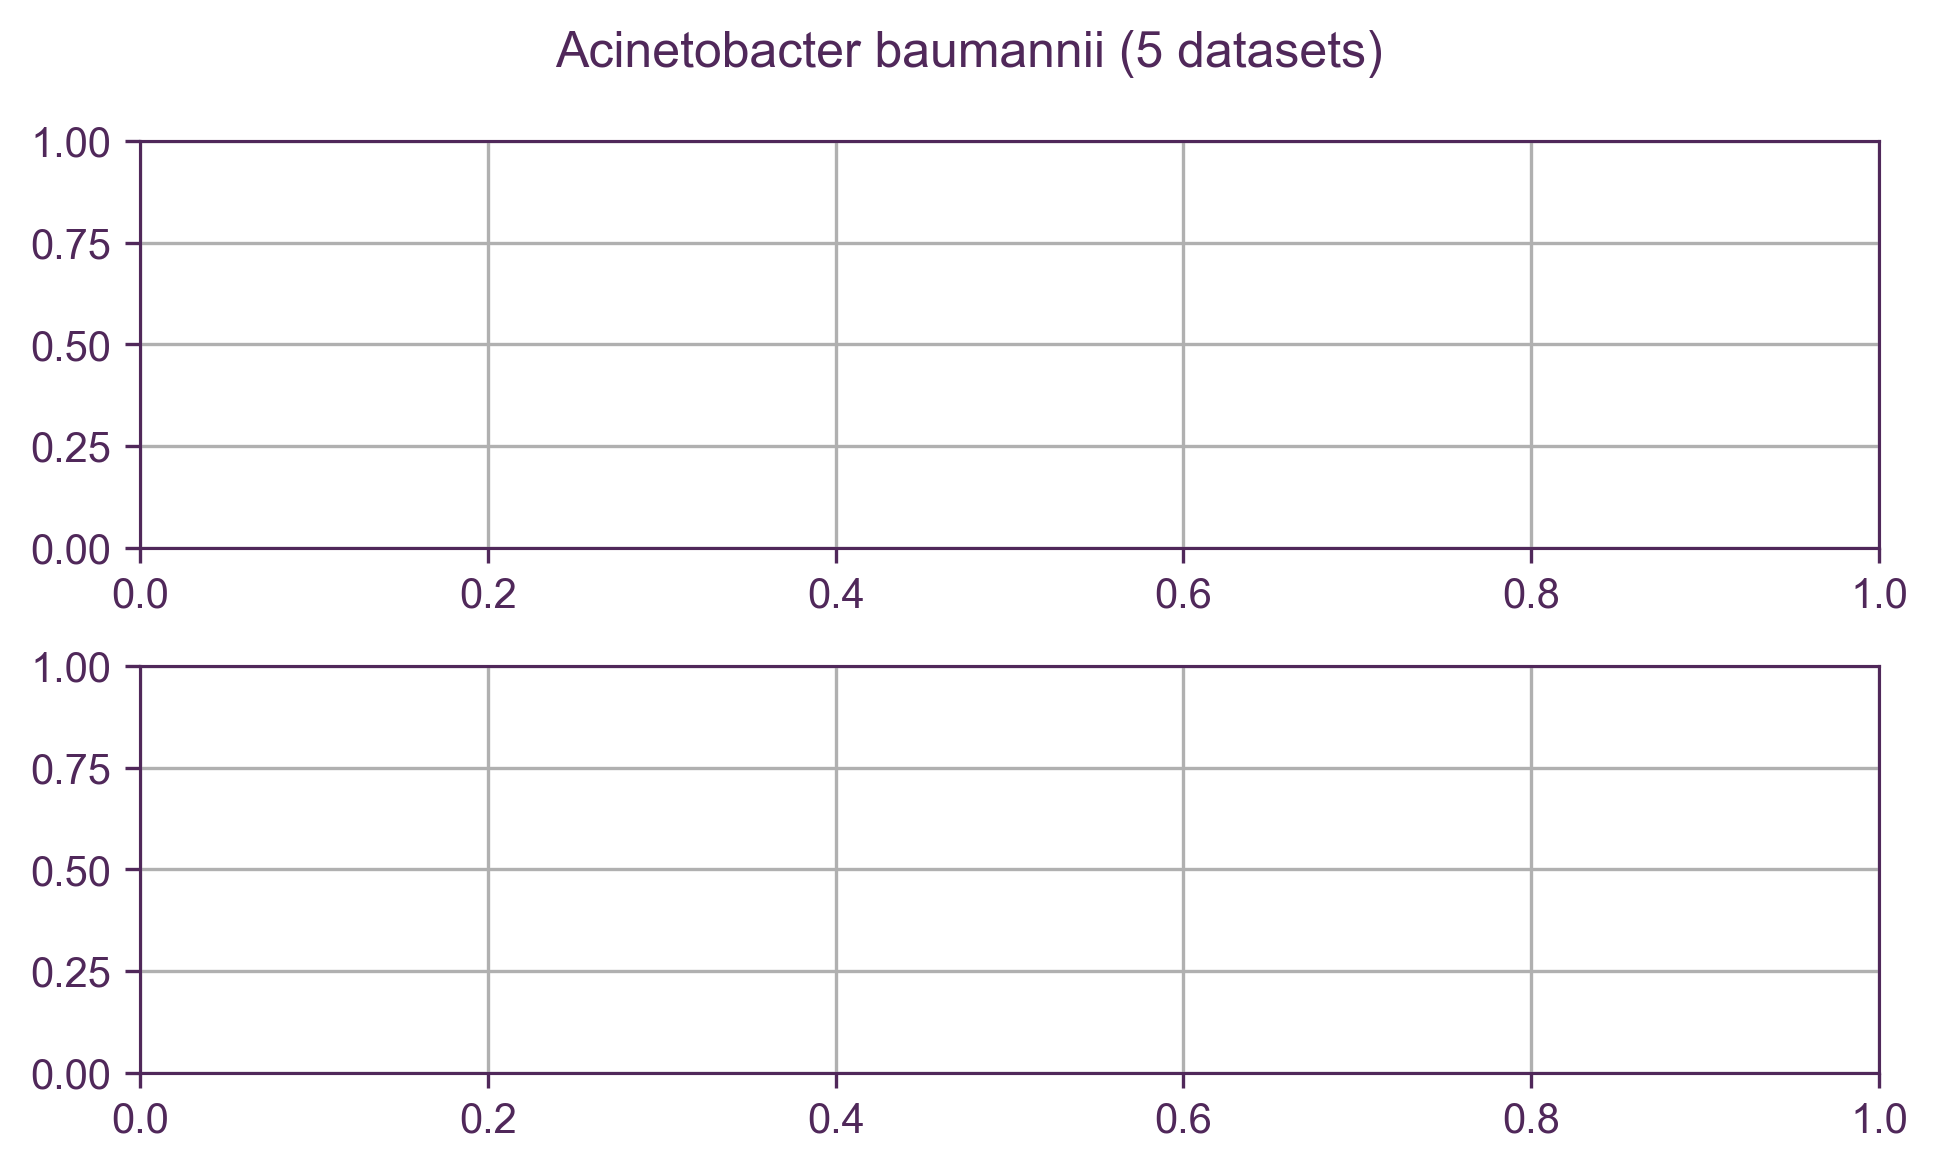

In [35]:
for pathogen in pathogens["code"]:

    print(f"Pathogen: {code_to_name[pathogen]}")
    numb_datasets = counts[counts['pathogen'] == pathogen]['n_datasets'].values[0]
    report_pathogen = report[report['pathogen'] == pathogen]
    print(f"Processed datasets: {len(report_pathogen)}/{numb_datasets}")

    
    # color = pal.get(8)[0]

    fig, axs = stylia.create_figure(2, 1, width=0.5, height=0.3)
    fig.suptitle(f"{code_to_name[pathogen]} ({numb_datasets} datasets)", fontsize=12)




    break

In [21]:
metadata

,pathogen,label,source,n_assays,name,activity_type,unit,target_type,cutoff,auroc,compounds,positives,ratio
0,abaumannii,A,individual,1,CHEMBL4296188_INHIBITION_%_qt_25.0,INHIBITION,%,ORGANISM,25.0,0.858,21494,171,0.008
1,abaumannii,M,merged,7,M_ORG3_20.0,MIC,umol.L-1,ORGANISM,20.0,0.978,279,151,0.541
2,abaumannii,G,general,2075,G_ORG0_10.0,MIC,umol.L-1,ORGANISM,10.0,0.922,7763,1971,0.254
3,abaumannii,G,general,86,G_ORG1_50.0,ACTIVITY,%,ORGANISM,50.0,0.902,112,58,0.518
4,abaumannii,G,general,63,G_ORG2_10.0,MIC50,umol.L-1,ORGANISM,10.0,0.898,127,50,0.394
...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,spneumoniae,M,merged,9,M_ORG3_r_10.0,MIC,umol.L-1,ORGANISM,10.0,0.983,103,75,0.728
348,spneumoniae,G,general,2638,G_ORG0_10.0,MIC,umol.L-1,ORGANISM,10.0,0.991,10648,7050,0.662
349,spneumoniae,G,general,211,G_ORG1_10.0,MIC50,umol.L-1,ORGANISM,10.0,0.966,152,99,0.651
350,spneumoniae,G,general,341,G_ORG2_10.0,MIC90,umol.L-1,ORGANISM,10.0,0.956,299,143,0.478


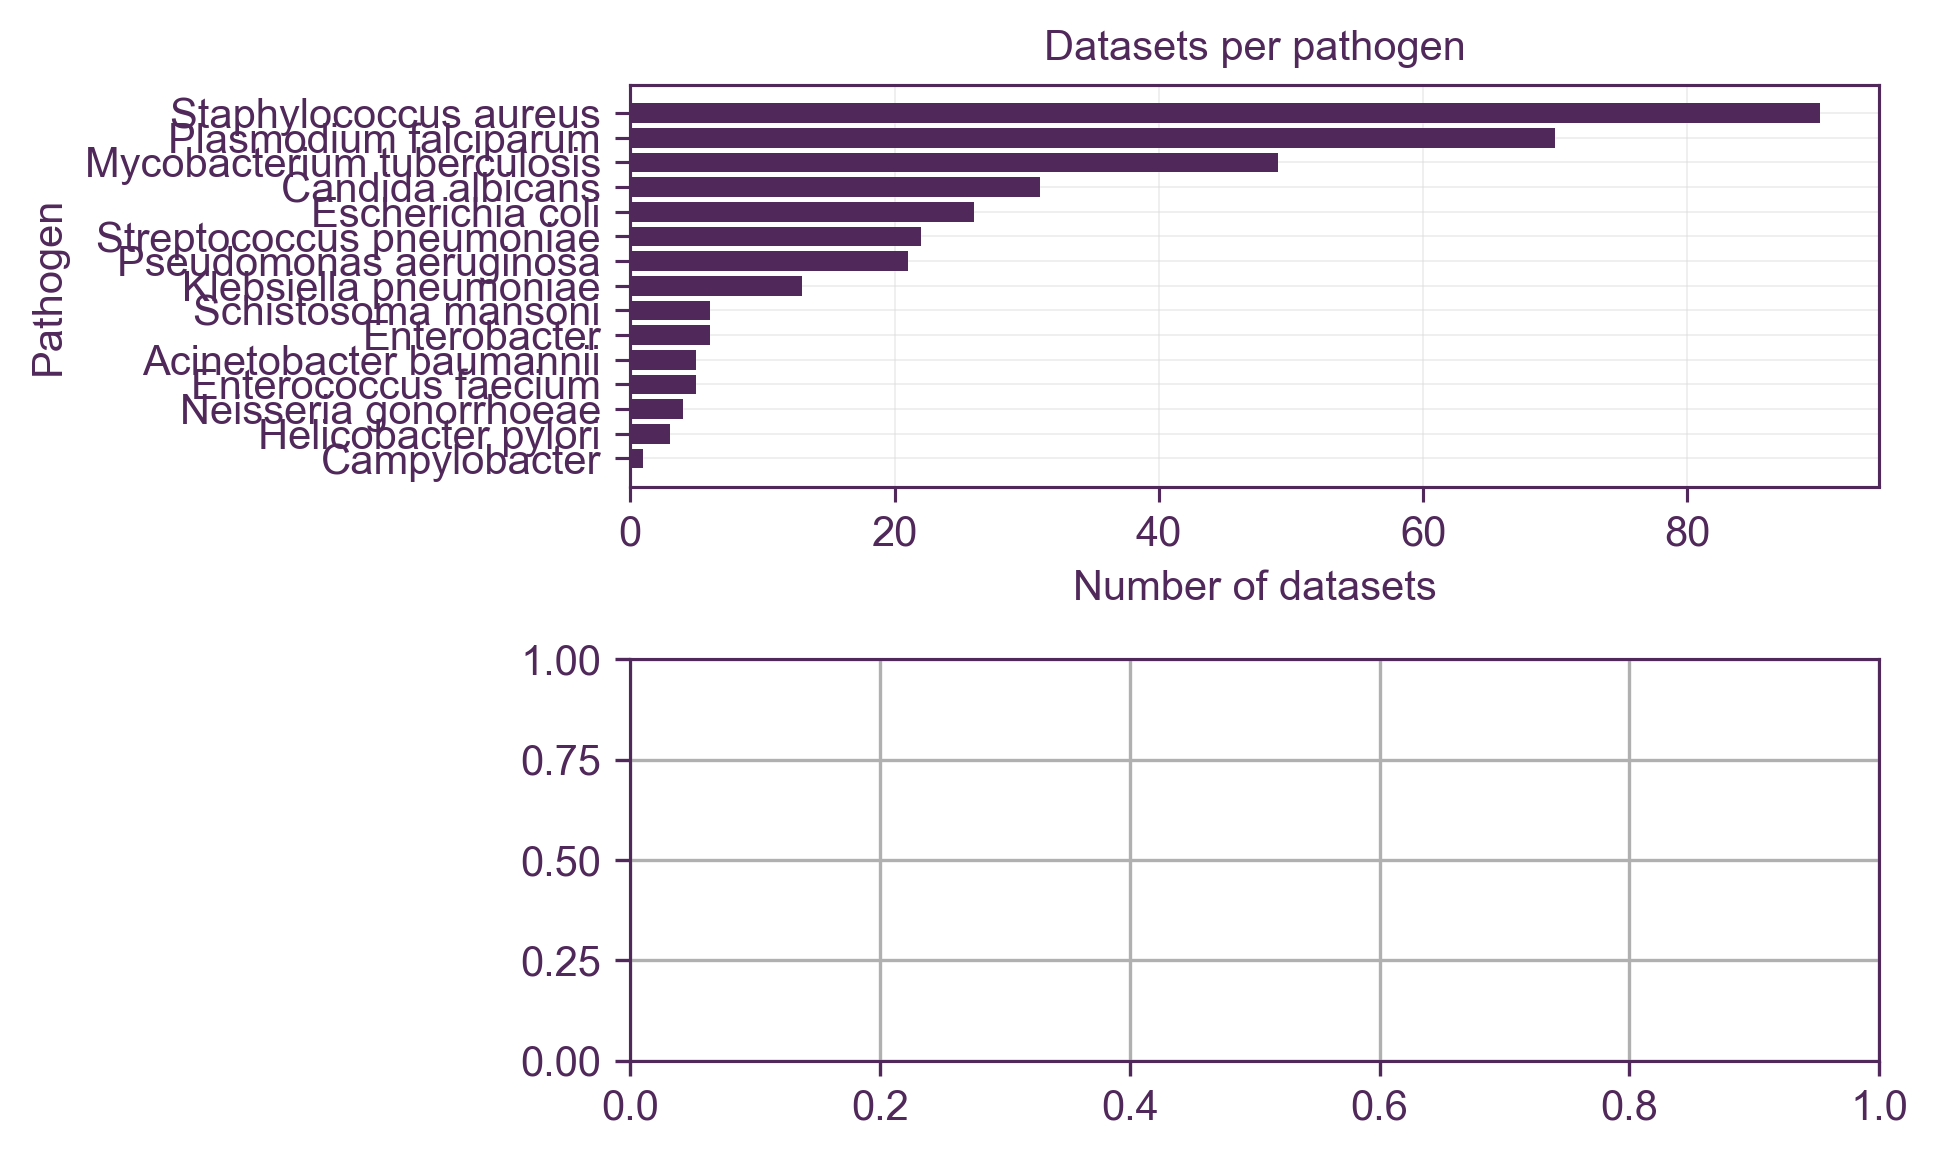

In [ ]:




# preserve pathogen order for the scatter
pathogen_order = counts["pathogen"].tolist()
metadata["name"] = metadata["pathogen"].map(code_to_name)
metadata["pathogen_rank"] = metadata["pathogen"].map({p: i for i, p in enumerate(pathogen_order)})

metadata = metadata.copy()
rng = np.random.default_rng(42)
jitter_strength = 0.18
metadata["pathogen_y_jitter"] = (
    metadata["pathogen_rank"] +
    rng.uniform(-jitter_strength, jitter_strength, size=len(metadata)))



ax_a = axs.next()
ax_a.barh(counts["pathogen_y"], counts["n_datasets"], color=color)
ax_a.set_yticks(counts["pathogen_y"])
ax_a.set_yticklabels(counts["name"])
ax_a.set_xlabel("Number of datasets")
ax_a.set_ylabel("Pathogen")
stylia.label(ax_a, title="Datasets per pathogen")